In LangGraph, conditional workflows allow for branching logic where the execution path is determined by specific conditions, similar to an if-else statement in traditional programming

Unlike parallel workflows where multiple branches execute simultaneously, a conditional workflow selects only one path based on the state at that moment

### Key Concepts of Conditional Workflows
1.Routing Function: To implement a conditional workflow, you must create a function (often called a routing or check-condition function) that examines the current state and returns the name of the next node or function to visit. 

2.add_conditional_edges: Instead of using the standard add_edge, you use add_conditional_edges. This function takes the starting node, the routing function, and (optionally) a mapping of return values to node names


NON LLM Workflow example : 
Quadratic Equation Workflow :
workflow to solve a quadratic equations . 


d = b**2 - 4ac 
if d > 0 -> 2 real roots (distinct)
if d == 0 -> 1 real root 
if d < 0 -> no real roots . 


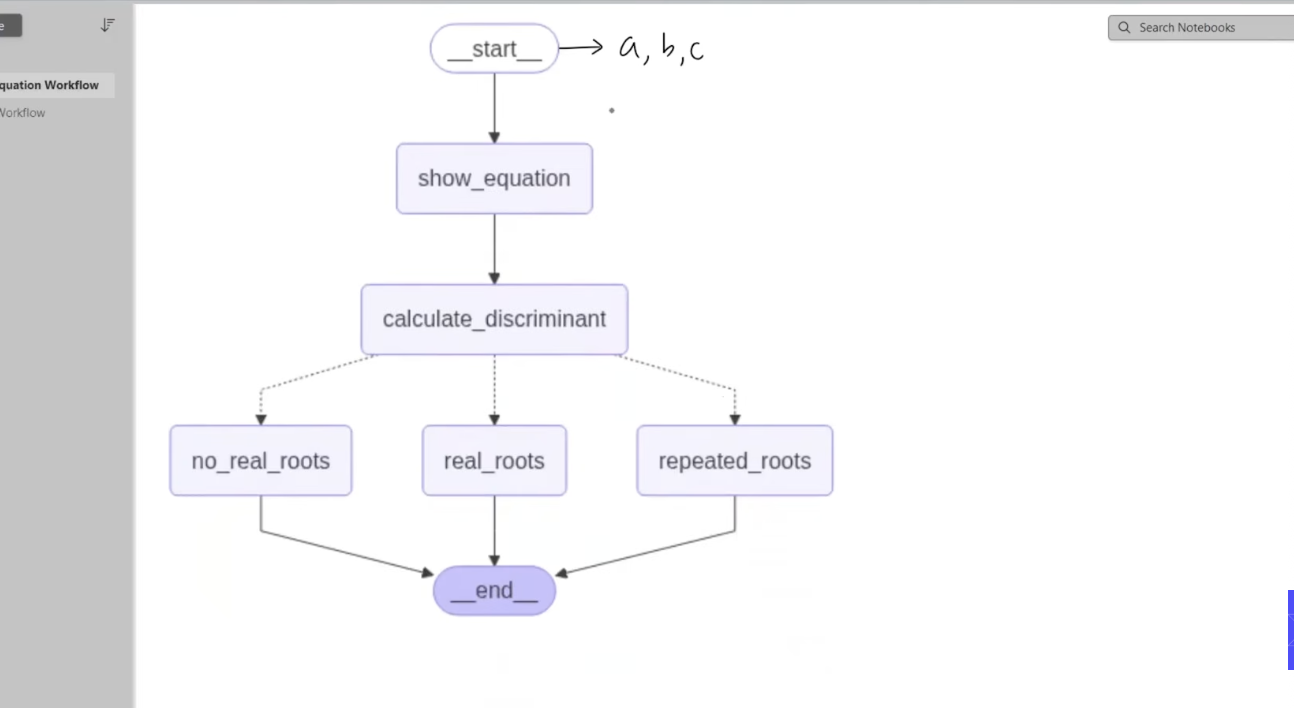

In [2]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal

# literal means it can only take specific value.
# Literal restricts a variable to specific constant values for safer and clearer type checking.
# it is only for type checking and does not enforce value restrictions at runtime.
# like we can still assign any value to a variable declared as Literal, but it will raise type checking errors in tools like mypy.



/Users/anantjain/Desktop/AI_Notes/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
# define state :
class QuadState(TypedDict):
    a : int 
    b : int 
    c : int 

    equation : str 
    discriminant : float 
    result : str 

In [4]:
def equation(state : QuadState) :
    equation = f"{state['a']}x² + {state['b']}x + {state['c']}"
    return {"equation": equation}

def cal_discr(state: QuadState):
    d = (state['b']**2) - (4 * state['a'] * state['c'])
    return {"discriminant": d}



def real_roots(state : QuadState):
    d = state['discriminant']
    r1 = (-state['b'] + d**0.5) / (2 * state['a'])
    r2 = (-state['b'] - d**0.5) / (2 * state['a'])
    return {"result": f"Two real roots: {r1} and {r2}"}

def repeated_roots(state: QuadState):
    r = -state['b'] / (2 * state['a'])
    return {"result": f"One repeated root: {r}"}


def no_real_roots(state: QuadState):
    return {"result": "No real roots"}


# it is a function which outputs another function : 

def check_condition(state : QuadState) -> Literal['real_roots' , 'repeated_roots' , 'no_real_roots']:
    if state['discriminant'] > 0 :
        return 'real_roots'
    elif state['discriminant'] == 0 :
        return 'repeated_roots' 
    else:
        return 'no_real_roots'

In [5]:
graph = StateGraph(QuadState)

graph.add_node('show_equation' , equation)
graph.add_node('cal_discr' , cal_discr)

# now we have to add three nodes , but only one will execute based on conditino 
graph.add_node('real_roots' , real_roots)
graph.add_node('repeated_roots' , repeated_roots)
graph.add_node('no_real_roots' , no_real_roots)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "cal_discr")


# condition : 
# to create a condition , we have to add conditional_edge 
graph.add_conditional_edges('cal_discr' , check_condition)
# first argument would be kis node se start kr rhe ho . 
# second function to check 

graph.add_edge('real_roots' , END)
graph.add_edge('repeated_roots' , END)
graph.add_edge('no_real_roots' , END)


workflow = graph.compile()


In [6]:
initial_state = {
    "a" : 4,
    'b' : 5,
    'c' : 4
    }
workflow.invoke(initial_state)


{'a': 4,
 'b': 5,
 'c': 4,
 'equation': '4x² + 5x + 4',
 'discriminant': -39,
 'result': 'No real roots'}

Project 2: Agentic Customer Support (LLM-based)
This workflow analyzes a customer review. using LLM  If the sentiment is positive, it generates a thank-you note. If negative, it performs a "diagnosis" (identifying issue type, tone, and urgency) before crafting an empathetic resolution

In [7]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel , Field
# Pydantic is a library used to validate and structure data using Python types.
# BaseModel is the core class in Pydantic.
# You inherit from it to create a data model with validation
# BaseModel is a way to define the structure of your data and ensure that it adheres to certain types and constraints.
import os
# Field is used to add extra constraints and metadata to model fields.



In [8]:
load_dotenv()

True

In [9]:
model = ChatGoogleGenerativeAI(api_key=os.getenv("GEMINI_API_KEY") , model="gemini-3-flash-preview")


In [22]:
class SentimentSchema(BaseModel):
    sentiment : Literal['positive' , 'negative' ] = Field(description="Sentiment of the review")
    

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [23]:
structured_model = model.with_structured_output(SentimentSchema)
# “Don’t give random text — return output in a fixed structured format.”
# its used when we speak to model and we want output in specific format , so we define a schema and then we use that schema to get output in that format.

structured_model2 = model.with_structured_output(DiagnosisSchema)

In [24]:
prompt = 'what is the sentiment of this review : "I love this product!"'
response = structured_model.invoke(prompt).sentiment
response

'positive'

In [25]:
# state 
class ReviewState(TypedDict):
    review : str 
    sentiment : Literal['positive' , 'negative']
    diagnosis : dict 
    response : str

In [26]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}
    

In [27]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()


In [28]:
workflow

KeyboardInterrupt: 

In [29]:

initial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(initial_state)


{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': [{'type': 'text',
   'text': 'Subject: Resolution regarding your report: [Issue Name/Reference Number]\n\nHi [User Name],\n\nThank you for your patience while we worked on this. I completely understand how frustrating it is to encounter a bug like this, especially when you have high-priority tasks depending on it. I know that downtime can be incredibly stressful, and I sincerely apologize for the disruption to your workflow.\n\nI’m reaching out to let you know that our engineering team has identified the root cause and successfully deployed a fix. \n\n**To ensure everything is working correctly on your end, please try the followin